In [1]:
from models.clustering import DeepEmbeddingClustering
from models.decomposition import Autoencoder
from models.user import UserFeaturePreprocessor, UserFeatureEngineering
from models.video import VideoFeaturePreprocessor
from models.interactions import InteractionFeaturePreprocessor
from models.moe import MixtureOfExperts
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from models.recommender import ndcg

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

pd.options.display.max_columns = None

In [2]:
users  = pd.read_csv('./data/KuaiRand-1k/data/user_clusters.csv')
videos = pd.read_csv('./data/KuaiRand-1k/data/video_clusters.csv')

In [3]:
train   = pd.read_csv('./data/KuaiRand-1k/data/log_standard_4_08_to_4_21_1k.csv', usecols=["user_id", "video_id",'play_time_ms', "time_ms", "is_profile_enter", "is_like", "long_view"])
train   = train[train.play_time_ms > 0]

X_train = InteractionFeaturePreprocessor.fit_transform((users, videos, train))
y_train = train[["is_like", "is_profile_enter", "long_view"]].values

In [4]:
test   = pd.read_csv('./data/KuaiRand-1k/data/log_standard_4_22_to_5_08_1k.csv', usecols=["user_id", "video_id",'play_time_ms', "time_ms", "is_profile_enter", "is_like", "long_view"])
test   = test[test.play_time_ms > 0]

X_test = InteractionFeaturePreprocessor.fit_transform((users, videos, test))
y_test = test[["is_like", "is_profile_enter", "long_view"]].values

In [8]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np


class Expert(nn.Module):
    """Feedforward expert network operating on a shared hidden representation."""
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Linear(hidden_dim * 2, hidden_dim)
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.net(X)


class MoELayer(nn.Module):
    """
    Mixture of Experts layer with noisy top-k gating to prevent expert collapse.

    Implements the noisy gating mechanism from Shazeer et al. (2017):
    - Adds learned, input-dependent noise to gate logits during training
    - This prevents early expert collapse by encouraging exploration
    - Returns full gate logits (pre-topk) for use in the auxiliary load loss

    Args:
        hidden_dim:   Dimension of the shared input/output representation
        num_experts:  Total number of expert networks
        k:            Number of experts to activate per token
    """
    def __init__(self, hidden_dim: int, num_experts: int, k: int = 2):
        super().__init__()
        self.k = k
        self.num_experts = num_experts
        self.hidden_dim = hidden_dim

        self.experts = nn.ModuleList([
            Expert(hidden_dim) for _ in range(num_experts)
        ])
        # Main gating network
        self.gate = nn.Linear(hidden_dim, num_experts)
        # Noise gating network — learns how much noise to inject per input
        self.noise_gate = nn.Linear(hidden_dim, num_experts)

    def forward(self, X: torch.Tensor):
        gate_logits = self.gate(X)

        # Inject learned noise during training to encourage exploration
        if self.training:
            noise_std = F.softplus(self.noise_gate(X))
            noise = torch.randn_like(gate_logits) * noise_std
            gate_logits = gate_logits + noise

        # Select top-k experts and compute normalised routing weights
        topk_logits, indices = torch.topk(gate_logits, self.k, dim=-1)
        weights = F.softmax(topk_logits, dim=-1)

        batch_size = X.size(0)
        combined_output = torch.zeros(batch_size, self.hidden_dim, device=X.device)

        for i in range(self.k):
            for expert_idx in range(self.num_experts):
                mask = (indices[:, i] == expert_idx)
                if mask.any():
                    expert_out = self.experts[expert_idx](X[mask])
                    combined_output[mask] += weights[mask, i].unsqueeze(1) * expert_out

        # Return full (pre-topk) logits so auxiliary loss sees all experts
        return combined_output, gate_logits


class MixtureOfExperts(nn.Module, BaseEstimator, TransformerMixin):
    """
    Mixture of Experts classifier/ranker compatible with sklearn Pipelines.

    Architecture:
        input -> LayerNorm -> input_proj -> MoELayer -> residual -> output_proj -> logits

    The MoE layer operates on a shared hidden_dim representation, meaning:
    - All experts share the same input/output dimensionality (hidden_dim)
    - input_proj learns a task-specific embedding before routing
    - output_proj maps the expert outputs to target space
    - A residual connection around the MoE layer stabilises training

    Gating uses noisy top-k routing (Shazeer 2017) to prevent expert collapse,
    combined with a variance-based load balancing auxiliary loss.

    Args:
        input_dim:       Number of input features
        output_dim:      Number of output targets (supports multi-label)
        hidden_dim:      Internal representation dimension (default: 128)
        num_experts:     Total number of expert networks (default: 8)
        k:               Number of active experts per forward pass (default: 2)
        epochs:          Maximum training epochs (default: 10)
        lr:              Adam learning rate (default: 1e-3)
        batch_size:      Training batch size (default: 32)
        min_delta:       Minimum val loss improvement for early stopping (default: 1e-4)
        patience:        Early stopping patience in epochs (default: 3)
        balancing_coef:  Weight of the load balancing auxiliary loss (default: 0.01)
        pareto_weights:  Per-output weights for transform() scoring (default: uniform)
        device:          Torch device string, e.g. 'cpu' or 'cuda' (default: 'cpu')
        seed:            Random seed for reproducibility (default: 42)
    """
    def __init__(
            self,
            input_dim: int,
            output_dim: int,
            hidden_dim: int = 128,
            num_experts: int = 8,
            k: int = 2,
            epochs: int = 10,
            lr: float = 1e-3,
            batch_size: int = 32,
            min_delta: float = 1e-4,
            patience: int = 3,
            balancing_coef: float = 0.01,
            pareto_weights: np.ndarray = None,
            device: str = "cpu",
            seed: int = 42
        ):
        super().__init__()

        # --- Sklearn-visible hyperparameters (names must match __init__ args) ---
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.num_experts = num_experts
        self.k = k
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.min_delta = min_delta
        self.patience = patience
        self.balancing_coef = balancing_coef
        self.pareto_weights = pareto_weights if pareto_weights is not None else np.ones(output_dim)
        self.device = device
        self.seed = seed

        # --- Architecture ---
        # _device is derived from self.device via property; not stored as attribute
        # to avoid breaking sklearn clone()
        self.norm = nn.LayerNorm(input_dim)
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.moe_layer_ = MoELayer(hidden_dim, num_experts, k)
        self.output_proj = nn.Linear(hidden_dim, output_dim)

        self.to(self._device)

    # --- Properties ---

    @property
    def _device(self) -> torch.device:
        """Derived from self.device so sklearn clone() doesn't need to track it."""
        return torch.device(self.device)

    # --- Public API ---

    def set_pareto_weights(self, weights: list):
        """Sets per-output business priority weights used in transform()."""
        if len(weights) != self.output_dim:
            raise ValueError(f"Expected {self.output_dim} weights, got {len(weights)}.")
        self.pareto_weights = np.array(weights, dtype=np.float32)

    def forward(self, X: torch.Tensor):
        """
        Forward pass through the full architecture.

        Args:
            X: (batch_size, input_dim)
        Returns:
            logits:      (batch_size, output_dim)
            gate_logits: (batch_size, num_experts) — used for load balancing loss
        """
        # Shared representation
        h = self.input_proj(self.norm(X))       # (B, hidden_dim)
        moe_out, gate_logits = self.moe_layer_(h)
        # Residual connection stabilises gradient flow through sparse routing
        h = h + moe_out                          # (B, hidden_dim)
        logits = self.output_proj(h)             # (B, output_dim)
        return logits, gate_logits

    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Fit the model using BCE loss with per-target class weighting.

        Supports both single-label (y shape: (n,)) and multi-label
        (y shape: (n, output_dim)) targets.
        """
        self._set_seed(self.seed)
        self.to(self._device)

        # Ensure y is always 2D: (n_samples, output_dim)
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        from sklearn.model_selection import train_test_split
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, random_state=self.seed
        )

        train_loader = DataLoader(
            TensorDataset(
                torch.tensor(X_train, dtype=torch.float32),
                torch.tensor(y_train, dtype=torch.float32),
            ),
            batch_size=self.batch_size,
            shuffle=True,
        )

        val_x = torch.tensor(X_val, dtype=torch.float32).to(self._device)
        val_y = torch.tensor(y_val, dtype=torch.float32).to(self._device)

        optimizer = optim.Adam(self.parameters(), lr=self.lr)

        # Per-target pos_weight: shape (output_dim,) handled correctly by BCE
        pos_count = y_train.sum(axis=0).clip(min=1)           # avoid div-by-zero
        neg_count = (len(y_train) - y_train.sum(axis=0)).clip(min=1)
        pos_weight = torch.tensor(
            neg_count / pos_count, dtype=torch.float32, device=self._device
        )
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_loss = float("inf")
        best_model_state = None
        counter = 0

        total_steps = self.epochs * len(train_loader)
        pbar = tqdm(total=total_steps, desc="Training MoE")

        for epoch in range(self.epochs):
            self.train()
            for batch_x, batch_y in train_loader:
                batch_x = batch_x.to(self._device)
                batch_y = batch_y.to(self._device)

                optimizer.zero_grad()
                preds, gate_logits = self.forward(batch_x)

                task_loss = criterion(preds, batch_y)

                # Load balancing: penalise variance of mean routing probability
                # across experts. Zero when all experts are used equally.
                # Uses full softmax (not topk) so all experts receive gradient signal.
                probs = F.softmax(gate_logits, dim=-1)   # (B, num_experts)
                importance = probs.mean(0)               # (num_experts,)
                load_loss = torch.var(importance) * self.num_experts

                total_loss = task_loss + self.balancing_coef * load_loss
                total_loss.backward()
                optimizer.step()

                pbar.update(1)
                pbar.set_postfix({"loss": f"{total_loss.item():.4f}", "epoch": epoch + 1})

            # Validation
            self.eval()
            with torch.no_grad():
                val_preds, _ = self.forward(val_x)
                current_val_loss = criterion(val_preds, val_y).item()

            pbar.set_postfix({"val_loss": f"{current_val_loss:.4f}", "best": f"{best_loss:.4f}"})

            if current_val_loss < best_loss - self.min_delta:
                best_loss = current_val_loss
                counter = 0
                best_model_state = self.state_dict()
            else:
                counter += 1
                if counter >= self.patience:
                    pbar.write(f"Early stopping at epoch {epoch + 1}")
                    pbar.update(total_steps - pbar.n)
                    break

        if best_model_state is not None:
            self.load_state_dict(best_model_state)

        pbar.close()
        # Sklearn check_is_fitted looks for attributes ending in '_'
        self.is_fitted_ = True
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Returns raw logits for all output targets.
        Shape: (n_samples, output_dim)
        """
        check_is_fitted(self, "is_fitted_")
        self.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32).to(self._device)
            preds, _ = self.forward(X_tensor)
            return preds.cpu().numpy()

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Returns sigmoid-activated probabilities.
        Shape: (n_samples, output_dim)
        """
        return torch.sigmoid(torch.tensor(self.predict(X))).numpy()

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Returns a single weighted score per sample using pareto_weights.
        Applies sigmoid first so all targets are on the same [0, 1] scale.
        Shape: (n_samples, 1)
        """
        probs = self.predict_proba(X)
        scores = np.dot(probs, self.pareto_weights)
        return scores.reshape(-1, 1)

    # --- Internals ---

    def _set_seed(self, seed: int):
        torch.manual_seed(seed)
        np.random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

In [9]:
device = "cuda"

reranker = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('video', MixtureOfExperts(
        input_dim=40,
        output_dim=3,
        num_experts=10,        # Increased for more specialized knowledge
        k=5,
        epochs=5,            # Increased to allow Gate to converge
        lr=1e-3,              # Slightly lower for more stability
        batch_size=10000,     # Smaller batches often help the Gate explore
        balancing_coef=0.05,  # Higher push for expert diversity
        device=device,
        seed=42
    )),
])

reranker.fit(X_train, y_train)

Training MoE: 100%|██████████| 1810/1810 [04:51<00:00,  6.21it/s, val_loss=0.8034, best=0.8303]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('video', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,input_dim,40
,output_dim,3
,hidden_dim,128
,num_experts,10


In [10]:
ranks = reranker.predict(X_test)
test['is_like_rank'] = ranks[:,0]
test['is_profile_enter_rank'] = ranks[:,1]
test['long_view_rank'] = ranks[:,2]


In [11]:

for by in ['is_like', 'is_profile_enter', 'long_view']:
    ranked = pd.concat([
        test[test[by]==1].sort_values(by=[by, 'time_ms'], ascending=[False, True]).groupby('user_id').agg(ideal_rank = ('video_id', list)),
        test.sort_values(by=['time_ms'], ascending=[True]).groupby('user_id').agg(curr_rank = ('video_id', list)),
        test.sort_values(by=[f'{by}_rank', 'time_ms'], ascending=[False, True]).groupby('user_id').agg(pred_rank = ('video_id', list))
    ], axis=1).dropna()
    print(by, ndcg(ranked.ideal_rank.values, ranked.curr_rank.values, k=5), ndcg(ranked.ideal_rank.values, ranked.pred_rank.values, k=5))



is_like 0.04130059704766538 0.019941046294836857
is_profile_enter 0.05344194832530651 0.03333870355031964
long_view 0.5075488842834435 0.2714115998927962


In [52]:
pd.DataFrame(y).corr()

,0,1,2
0,1.000000,0.057136,0.089170
1,0.057136,1.000000,0.134566
2,0.089170,0.134566,1.000000


In [38]:
ranked

,ideal_rank,curr_rank,pred_rank
user_id,,,
0,"[1033272, 2187381, 1870951, 2185068, 1818365, ...","[554434, 3800048, 2133392, 2019165, 1033272, 1...","[417290, 3070601, 1798332, 3272057, 301212, 18..."
1,"[3069022, 3381881, 608447, 2879949, 4369557, 1...","[3069022, 4325558, 2879949, 3483243, 608447, 3...","[712934, 1793628, 4304797, 3044654, 4199563, 1..."
2,"[1365678, 2124902, 218204, 2949346, 4201054, 5...","[1804415, 1965557, 2124902, 1365678, 2370352, ...","[1569375, 754398, 3237045, 305274, 3078609, 87..."
3,"[2670972, 2342479, 3959765, 980068, 3983494, 4...","[1028581, 2342479, 2799207, 2670972, 589314, 3...","[1969639, 1751595, 305274, 1718828, 406176, 41..."
4,"[1578084, 1499437, 3111045, 535289, 3363489, 1...","[1578084, 880014, 1499437, 3111045, 2585901, 5...","[3062493, 4120230, 1726515, 4055620, 1969456, ..."
...,...,...,...
995,"[4284891, 1816792, 3983494, 567129, 2462749, 3...","[4052089, 2739043, 3396932, 4284891, 1816792, ...","[3058711, 72937, 2693612, 2559092, 4097110, 38..."
996,"[1332779, 4070235, 394961, 1778238, 2084156, 1...","[1723379, 2028566, 2395867, 1332779, 466640, 1...","[1685754, 2693612, 4254321, 417290, 3149, 1008..."
997,"[1286074, 2538316, 1990885, 2858182, 890346, 2...","[1286074, 2538316, 2858182, 1990885, 2110119, ...","[156872, 3596235, 1977409, 832694, 3487485, 41..."


c:\Users\rober\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(
c:\Users\rober\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(
c:\Users\rober\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(
c:\Users\rober\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


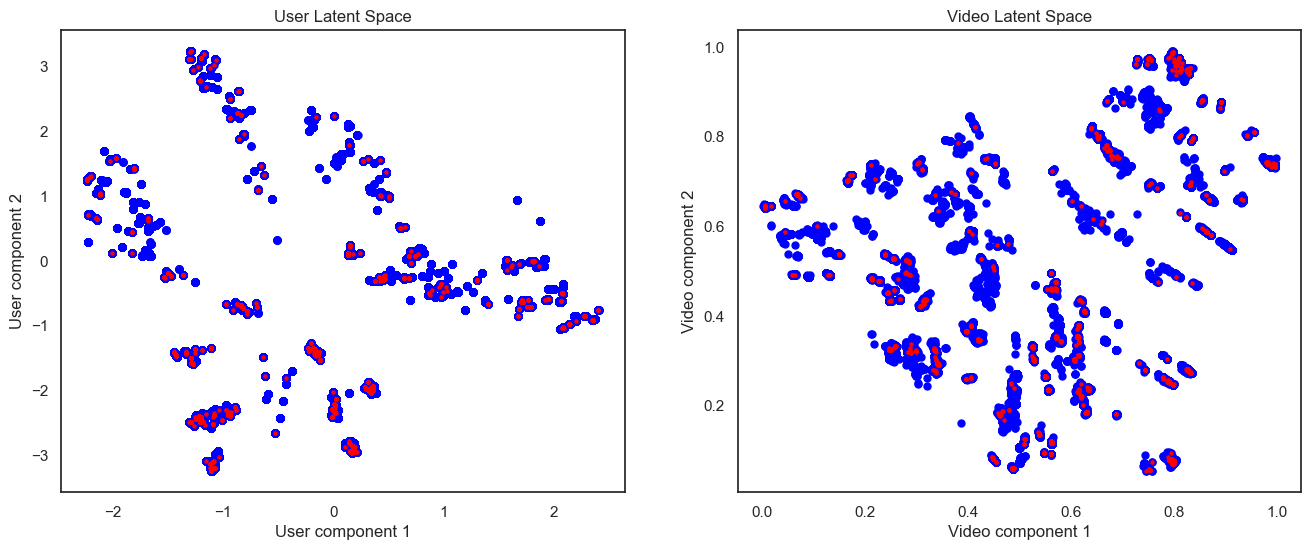

In [54]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sample and sort once to ensure consistency
plot_data = interactions.sample(100000).sort_values('User liked')
size = [25, 5]
color = ['blue','red']
for i in [0, 1]:
    # Plot 1: User Components
    plot_data[plot_data['User liked'] == i].plot.scatter(
        x='User component 1', 
        y='User component 2', 
        c=color[i], 
        s=size[i], 
        alpha=1.0, 
        cmap='coolwarm', 
        ax=axes[0],
        colorbar=False # Manage colorbar separately for a cleaner look
    )
    axes[0].set_title('User Latent Space')

    # Plot 2: Video Components
    plot_data[plot_data['User liked'] == i].plot.scatter(
        x='Video component 1', 
        y='Video component 2', 
        c=color[i], 
        s=size[i], 
        alpha=1.0, 
        cmap='coolwarm', 
        ax=axes[1],
        colorbar=False
    )
    axes[1].set_title('Video Latent Space')

# Add a single colorbar for both plots
# fig.colorbar(scatter.collections[0], ax=axes, label='User liked')

plt.show();

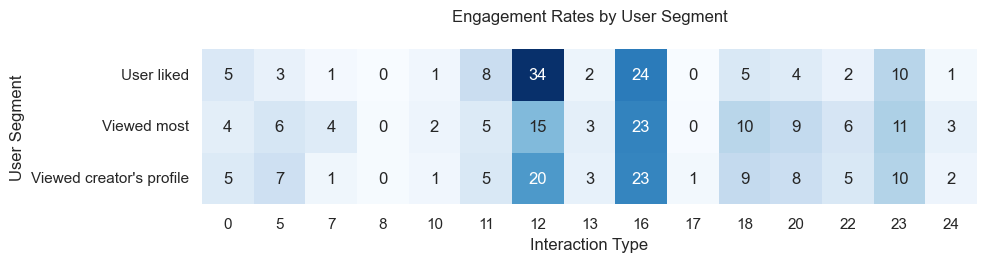

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate rates instead of sums
segment_rates = (interactions.groupby('User segment')[["User liked", "Viewed most", "Viewed creator's profile"]].sum())
segment_rates = segment_rates.apply(lambda x: x/x.sum()) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(
    segment_rates.transpose(), 
    annot=True, 
    fmt=".0f", # Display one decimal place
    cmap="Blues", 
    cbar=False,
    cbar_kws={'label': 'Engagement Rate (%)'},
    square=True
)

plt.title('Engagement Rates by User Segment', pad=20)
plt.xlabel('Interaction Type')
plt.ylabel('User Segment')
plt.show()

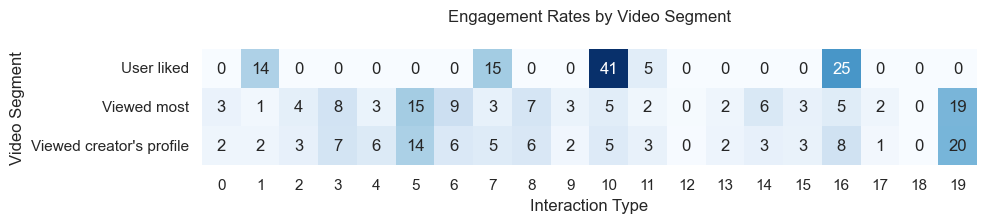

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate rates instead of sums
segment_rates = (interactions.groupby('Video segment')[["User liked", "Viewed most", "Viewed creator's profile"]].sum())
segment_rates = segment_rates.apply(lambda x: x/x.sum()) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(
    segment_rates.transpose(), 
    annot=True, 
    fmt=".0f", # Display one decimal place
    cmap="Blues", 
    cbar=False,
    cbar_kws={'label': 'Engagement Rate (%)'},
    square=True
)

plt.title('Engagement Rates by Video Segment', pad=20)
plt.xlabel('Interaction Type')
plt.ylabel('Video Segment')
plt.show()